In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv("Clean_Dataset.csv")
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [7]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [9]:
df.head(5)
df.tail(5)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [10]:
df.nunique()

,0
Unnamed: 0,300153
airline,6
flight,1561
source_city,6
departure_time,6
stops,3
arrival_time,6
destination_city,6
class,2
duration,476


In [11]:
df["airline"].value_counts()

,count
airline,
Vistara,127859
Air_India,80892
Indigo,43120
GO_FIRST,23173
AirAsia,16098
SpiceJet,9011


In [12]:
print(df['stops'].unique())

['zero' 'one' 'two_or_more']


In [13]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [14]:
df.drop(columns=["Unnamed: 0"],inplace = True)

In [15]:
df.columns.tolist()

['airline',
 'flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class',
 'duration',
 'days_left',
 'price']

In [16]:
for col in ['airline', 'stops', 'source_city','class','destination_city'] :
  print(col + ":")
  print(df[col].value_counts())

airline:
airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64
stops:
stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64
source_city:
source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64
class:
class
Economy     206666
Business     93487
Name: count, dtype: int64
destination_city:
destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64


In [17]:
# Convert stops from text to numbers
df['stops'] = df['stops'].map({'zero': 0, 'one': 1, 'two_or_more': 2})

# Verify it worked
print(df['stops'].value_counts())
print(df['stops'].dtype)

stops
1    250863
0     36004
2     13286
Name: count, dtype: int64
int64


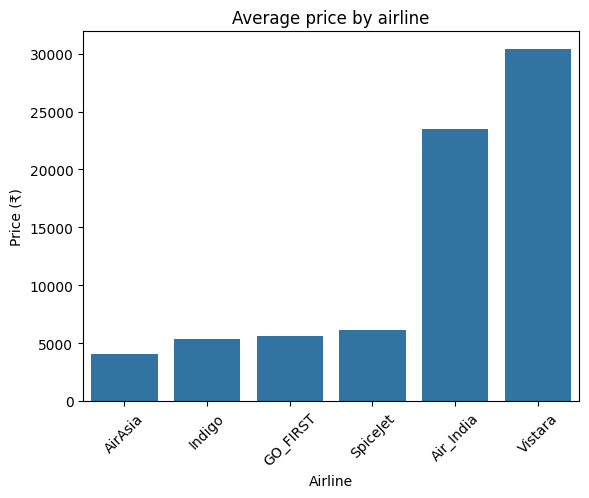

In [18]:
mean = df.groupby('airline')['price'].mean().sort_values()
sns.barplot(x= mean.index , y = mean.values)
plt.title('Average price by airline')
plt.xlabel('Airline')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45)
plt.show()

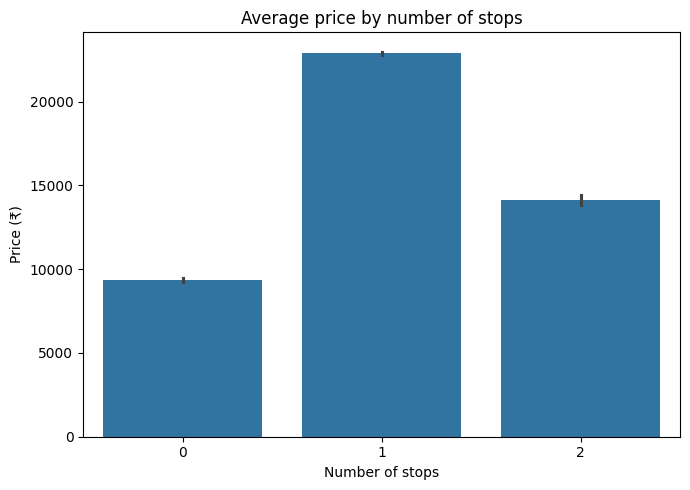

In [19]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='stops', y='price')
plt.title('Average price by number of stops')
plt.xlabel('Number of stops')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

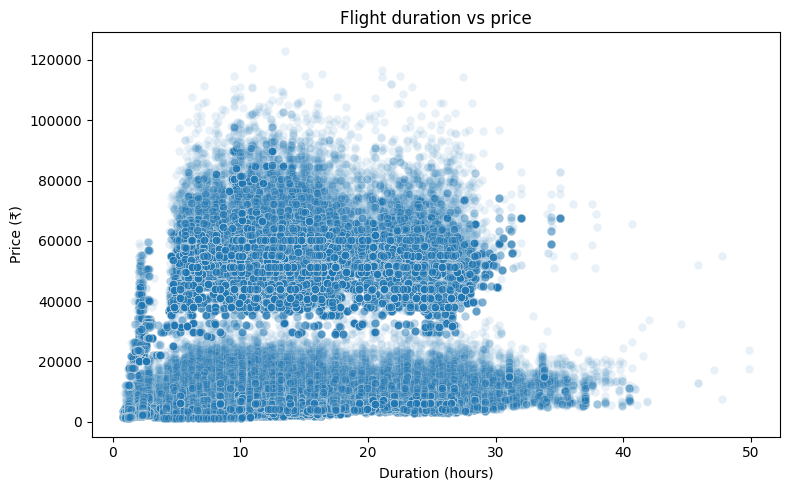

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='duration', y='price', alpha=0.1)
plt.title('Flight duration vs price')
plt.xlabel('Duration (hours)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

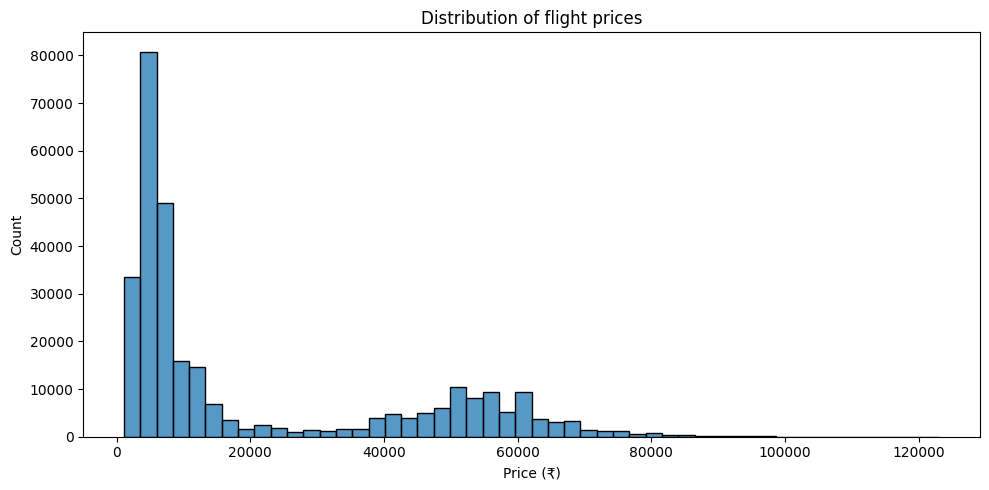

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50)
plt.title('Distribution of flight prices')
plt.xlabel('Price (₹)')
plt.tight_layout()
plt.show()

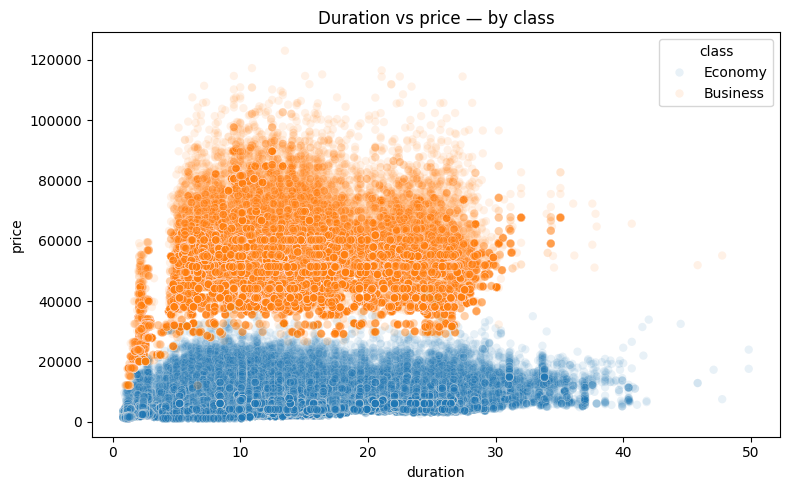

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='duration', y='price', hue='class', alpha=0.1)
plt.title('Duration vs price — by class')
plt.tight_layout()
plt.show()

In [23]:
df.corr(numeric_only=True)

,stops,duration,days_left,price
stops,1.000000,0.468059,-0.008540,0.119648
duration,0.468059,1.000000,-0.039157,0.204222
days_left,-0.008540,-0.039157,1.000000,-0.091949
price,0.119648,0.204222,-0.091949,1.000000


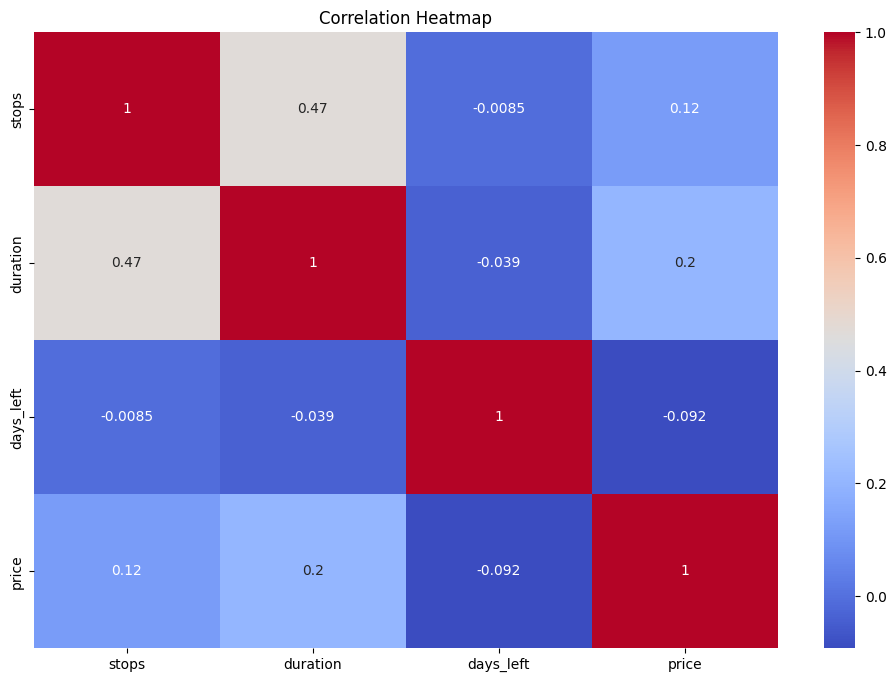

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()